In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import os
import matplotlib.pyplot as plt

# Import your architecture components
from DCGAN.vectorized_unet import VectorizedUNet
from DCGAN.unet import UNet
from DCGAN.loss_functions import EntropyLoss, TotalVariationLoss

# ── 1. Dummy Dataset ────────────────────────────────────────────────────────
class DummyShapeDataset(Dataset):
    def __init__(self, num_samples=1000, size=256, max_shapes_per_image=3):
        self.num_samples = num_samples
        self.size = size
        self.max_shapes = max_shapes_per_image
        # Pyramids required by VectorizedUNet
        self.resolutions = [4, 8, 16, 32, 64, 128, 256]
        
    def __len__(self):
        return self.num_samples
        
    def __getitem__(self, idx):
        # 1. White background [3, H, W] -> R=1, G=1, B=1
        img = torch.ones(3, self.size, self.size)
        
        # 2. Add random number of Yellow squares -> R=1, G=1, B=0
        num_squares = torch.randint(1, self.max_shapes + 1, (1,)).item()
        for _ in range(num_squares):
            s = torch.randint(20, 60, (1,)).item() # Size
            y = torch.randint(0, self.size - s, (1,)).item()
            x = torch.randint(0, self.size - s, (1,)).item()
            img[0, y:y+s, x:x+s] = 1.0
            img[1, y:y+s, x:x+s] = 1.0
            img[2, y:y+s, x:x+s] = 0.0
            
        # 3. Add random number of Blue circles -> R=0, G=0, B=1
        num_circles = torch.randint(1, self.max_shapes + 1, (1,)).item()
        for _ in range(num_circles):
            r = torch.randint(10, 30, (1,)).item() # Radius
            cy = torch.randint(r, self.size - r, (1,)).item()
            cx = torch.randint(r, self.size - r, (1,)).item()
            
            y_grid, x_grid = torch.meshgrid(
                torch.arange(self.size), torch.arange(self.size), indexing='ij'
            )
            mask = ((y_grid - cy)**2 + (x_grid - cx)**2) <= r**2
            img[0, mask] = 0.0
            img[1, mask] = 0.0
            img[2, mask] = 1.0
            
        # 4. Scale to [-1, 1] for Tanh
        img = img * 2.0 - 1.0
        
        # 5. Create multi-resolution pyramid
        img_pyramid = []
        for res in self.resolutions:
            if res == self.size:
                img_pyramid.append(img)
            else:
                # Downsample for smaller resolutions
                down = F.adaptive_avg_pool2d(img.unsqueeze(0), (res, res)).squeeze(0)
                img_pyramid.append(down)
                
        return img_pyramid, 0 # Return 0 for dummy target

# ── 2. Training Setup ───────────────────────────────────────────────────────


In [22]:
import matplotlib.pyplot as plt

def visualize_results(orig_img, recon_img, masks, epoch, batch_idx):
    """
    orig_img: [C, H, W] tensor
    recon_img: [C, H, W] tensor
    masks: [K, H, W] tensor (probabilities from softmax)
    """
    # Detach, move to CPU, and format for matplotlib
    # Assuming images are normalized [-1, 1], adjust to [0, 1]
    orig = (orig_img.detach().cpu() * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()
    recon = (recon_img.detach().cpu() * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()
    m = masks.detach().cpu().numpy() # [K, H, W]
    
    K = m.shape[0] # Number of masks
    
    # Setup dynamic subplots: 1 for Orig, 1 for Recon, K for Masks
    fig, axes = plt.subplots(1, 2 + K, figsize=(4 + 3 * K, 4))
    
    # Plot Original
    axes[0].imshow(orig)
    axes[0].set_title("Original")
    axes[0].axis('off')
    
    # Plot Reconstruction
    axes[1].imshow(recon)
    axes[1].set_title("Reconstruction")
    axes[1].axis('off')
    
    # Plot Each Mask
    for i in range(K):
        ax = axes[2 + i]
        im = ax.imshow(m[i], cmap='viridis', vmin=0, vmax=1)
        ax.set_title(f"Mask {i}")
        ax.axis('off')
        
    plt.suptitle(f"Epoch {epoch} | Batch {batch_idx}")
    plt.tight_layout()
    plt.show()
    # plt.savefig(f"vis_ep{epoch}_b{batch_idx}.png") # Use this if running on a remote server without GUI
    # plt.close()

In [23]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Hyperparameters from your notebook
n_components = 3  # Background, Squares, Circles
encoder_channels = [512, 256, 128, 64, 32, 32, 16]
decoder_channels = [64, 32, 32, 16, 16, 16, 16]

# NOTE: Set the first DOF to 512 to avoid the assertion crash with z_dim=512!
degrees_of_freedom = [1, 1, 1, 1, 1, 1, 1]
vectorizer_output_channels = [1, 1, 1, 1, 1, 1]
grid_sizes = [1, 2, 4, 4, 8, 8, 16] 
z_dim  =1
seg_gen_cut_connections = 4
batch_size = 16
epochs = 10

# Datasets
train_ds = DummyShapeDataset(num_samples=1000)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

# Models
rec_model = VectorizedUNet(
    encoder_channels=encoder_channels,
    decoder_channels=decoder_channels,
    number_of_components=n_components,
    vectorizer_output_channels=vectorizer_output_channels,
    degrees_of_freedom=degrees_of_freedom,
    grid_sizes=grid_sizes,
    z_dim=z_dim
).to(device)

seg_model = UNet(
    channels=encoder_channels,
    out_channels=n_components,
    cut_connections=seg_gen_cut_connections
).to(device)

# Optimizers
rec_optimizer = optim.Adam(rec_model.parameters(), lr=2e-4)
seg_optimizer = optim.Adam(seg_model.parameters(), lr=2e-4)

# Loss Functions
recon_loss_fn = nn.L1Loss()
entropy_loss_fn = EntropyLoss(weight=0.0001)
tv_loss_fn = TotalVariationLoss(weight=0.001)


Using device: cuda


Epoch 0/10:   0%|          | 0/63 [00:00<?, ?it/s, entropy_loss=0.000101, recon_loss=0.612, tv_loss=6.55e-6]

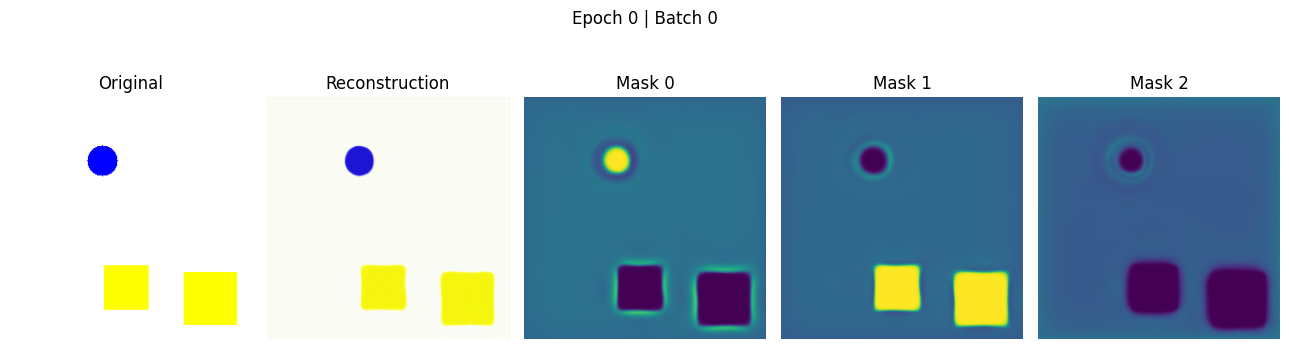

Epoch 0/10:  32%|███▏      | 20/63 [00:05<00:10,  4.01it/s, entropy_loss=0.0001, recon_loss=0.677, tv_loss=7.24e-6]  

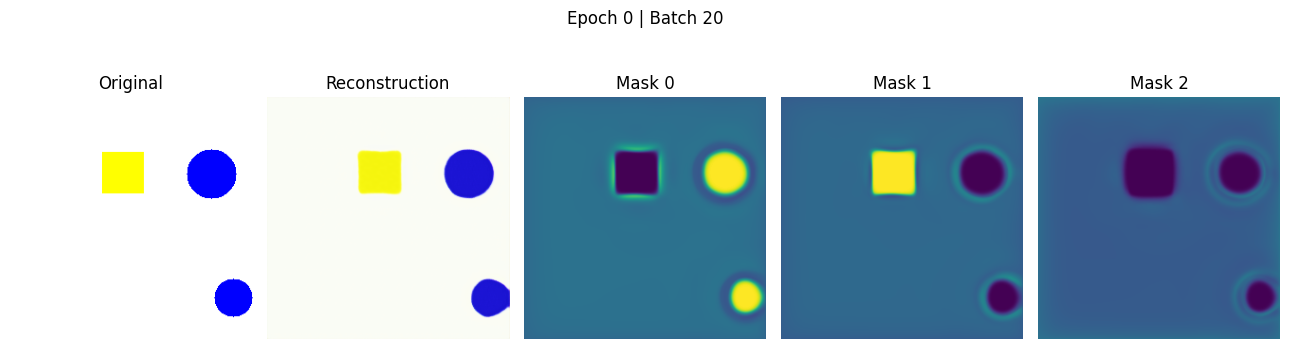

Epoch 0/10:  63%|██████▎   | 40/63 [00:10<00:05,  4.04it/s, entropy_loss=0.000102, recon_loss=0.583, tv_loss=6.55e-6]

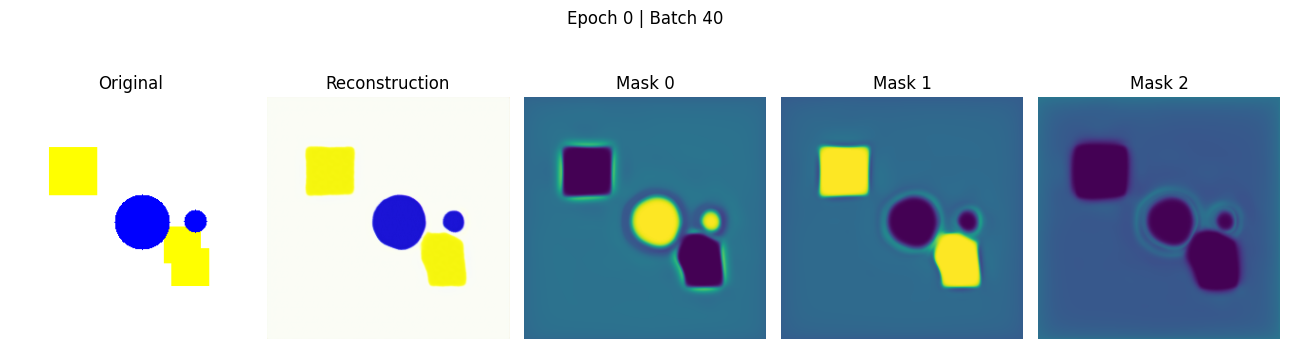

Epoch 0/10:  95%|█████████▌| 60/63 [00:15<00:00,  4.02it/s, entropy_loss=0.000102, recon_loss=0.602, tv_loss=6.65e-6]

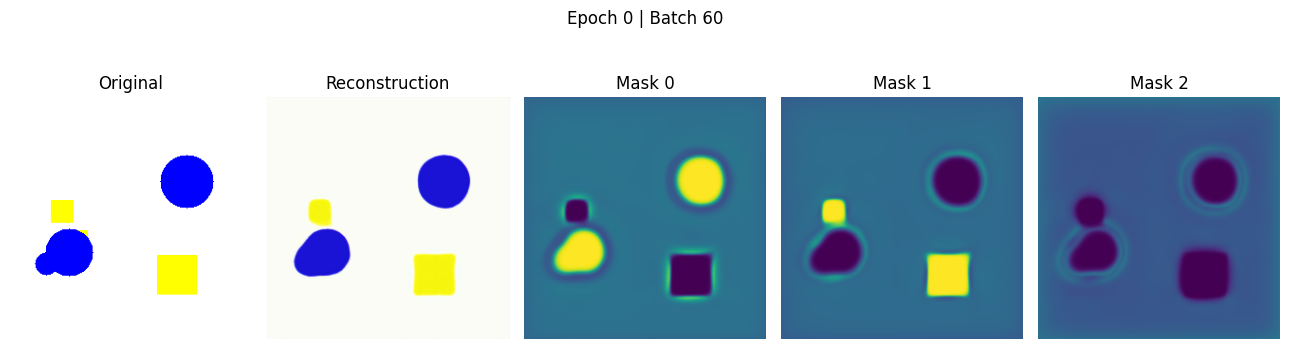

Epoch 0/10: 100%|██████████| 63/63 [00:16<00:00,  3.84it/s, entropy_loss=0.0001, recon_loss=0.632, tv_loss=7.03e-6]  


Epoch 0 complete. Recon Loss: 0.6317


Epoch 1/10:   0%|          | 0/63 [00:00<?, ?it/s, entropy_loss=0.0001, recon_loss=0.644, tv_loss=7.25e-6]

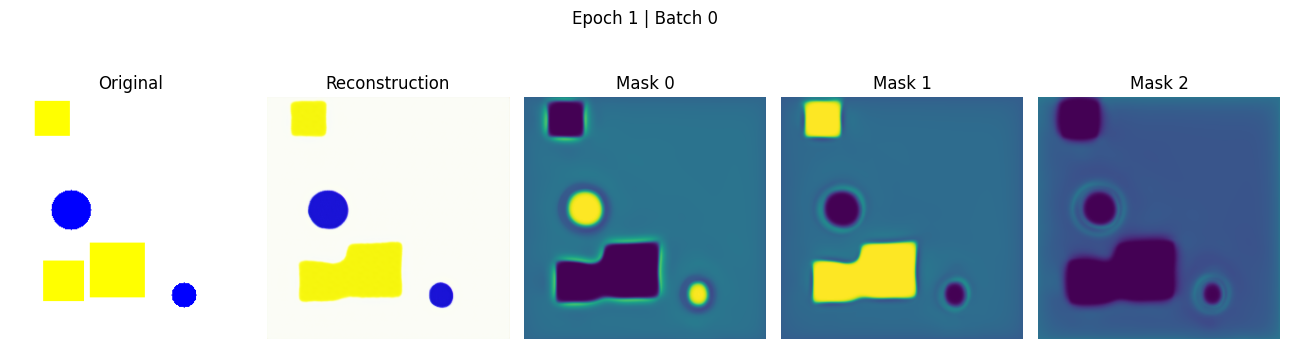

Epoch 1/10:  32%|███▏      | 20/63 [00:05<00:10,  4.05it/s, entropy_loss=9.99e-5, recon_loss=0.621, tv_loss=7.25e-6] 

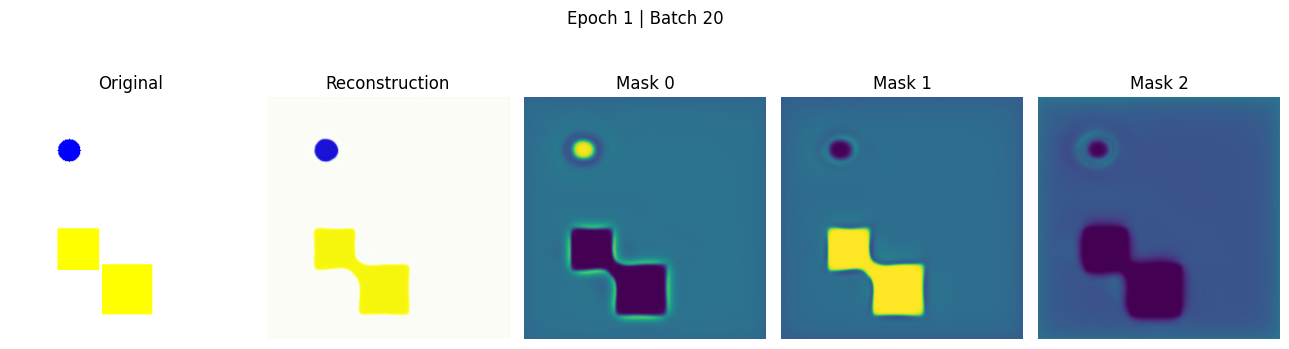

Epoch 1/10:  63%|██████▎   | 40/63 [00:10<00:05,  4.02it/s, entropy_loss=0.000101, recon_loss=0.58, tv_loss=6.81e-6] 

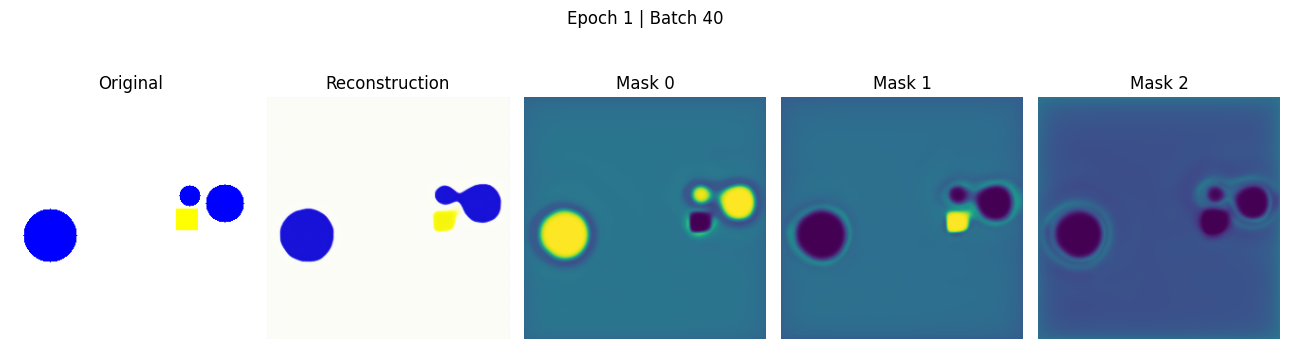

Epoch 1/10:  95%|█████████▌| 60/63 [00:15<00:00,  4.04it/s, entropy_loss=9.91e-5, recon_loss=0.643, tv_loss=7.81e-6] 

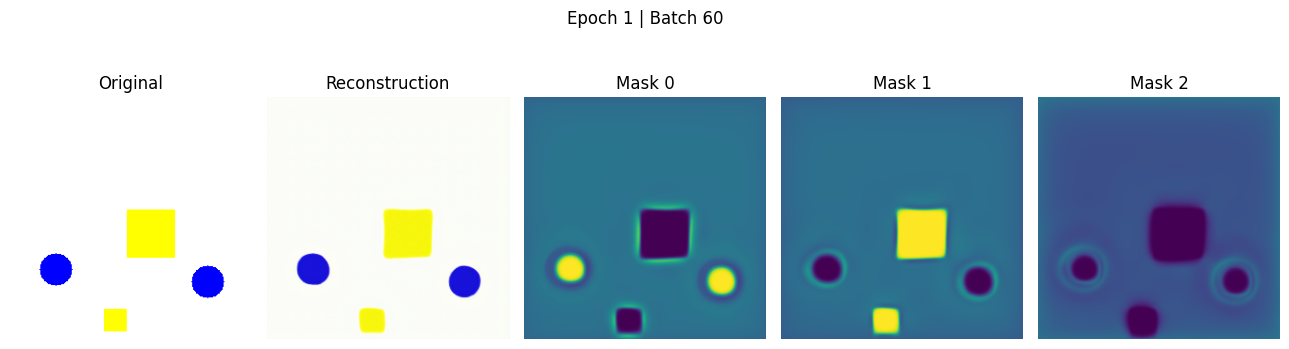

Epoch 1/10: 100%|██████████| 63/63 [00:16<00:00,  3.83it/s, entropy_loss=0.000103, recon_loss=0.531, tv_loss=6.48e-6]


Epoch 1 complete. Recon Loss: 0.5312


Epoch 2/10:   0%|          | 0/63 [00:00<?, ?it/s, entropy_loss=0.000101, recon_loss=0.603, tv_loss=7.36e-6]

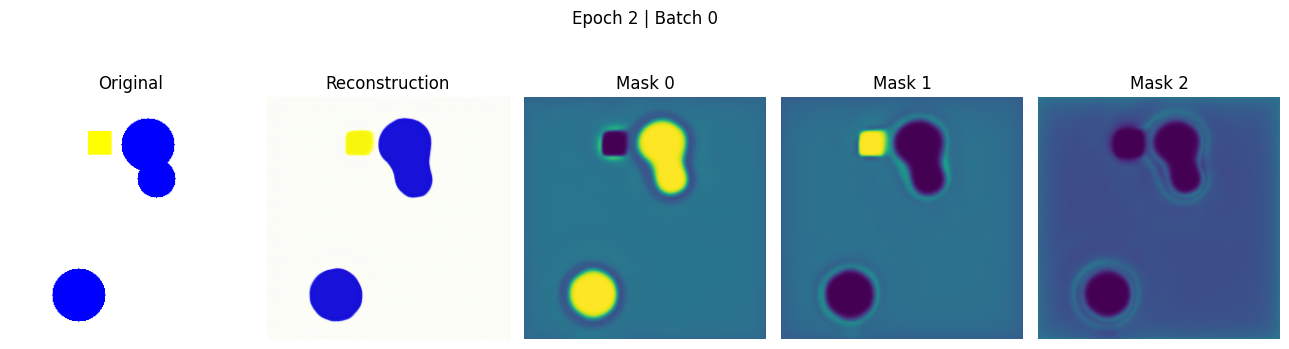

Epoch 2/10:  32%|███▏      | 20/63 [00:05<00:10,  4.03it/s, entropy_loss=0.000101, recon_loss=0.535, tv_loss=6.87e-6]

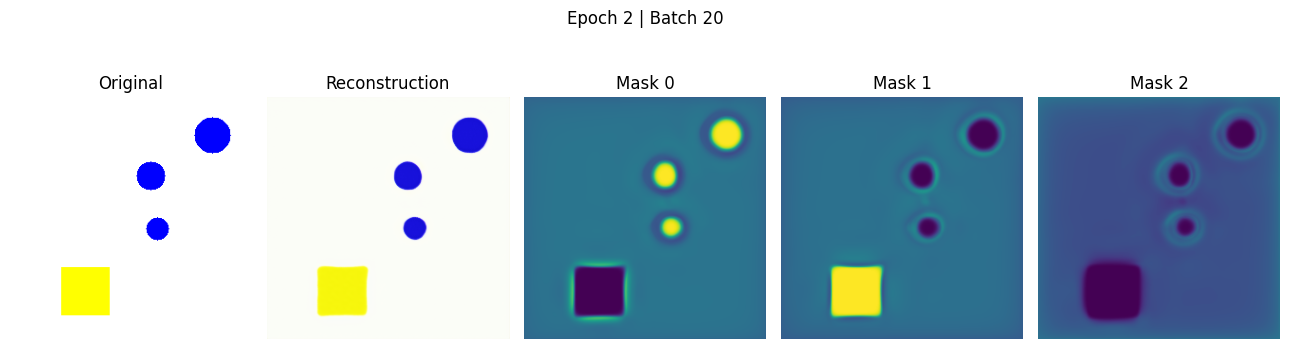

Epoch 2/10:  63%|██████▎   | 40/63 [00:10<00:05,  4.14it/s, entropy_loss=9.95e-5, recon_loss=0.589, tv_loss=7.76e-6] 

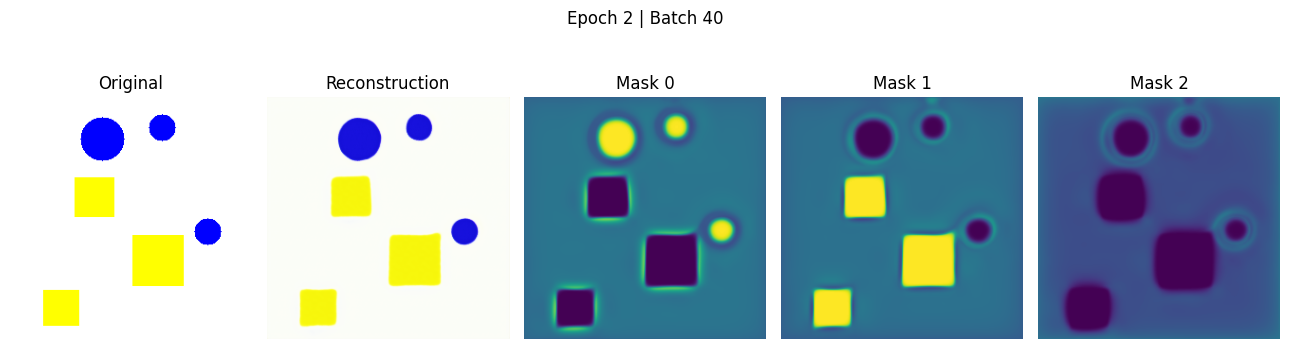

Epoch 2/10:  95%|█████████▌| 60/63 [00:15<00:00,  4.12it/s, entropy_loss=9.84e-5, recon_loss=0.647, tv_loss=8.08e-6] 

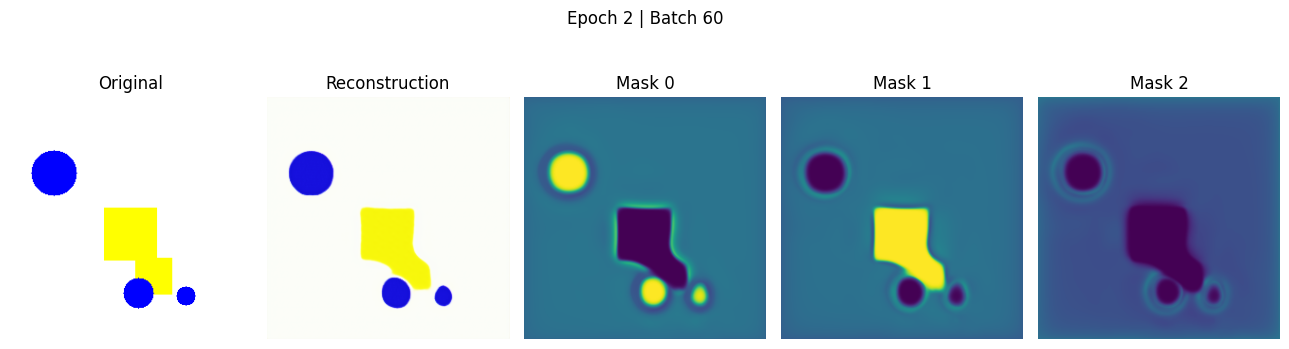

Epoch 2/10: 100%|██████████| 63/63 [00:16<00:00,  3.89it/s, entropy_loss=9.83e-5, recon_loss=0.626, tv_loss=7.82e-6]


Epoch 2 complete. Recon Loss: 0.6262


Epoch 3/10:   0%|          | 0/63 [00:00<?, ?it/s, entropy_loss=9.94e-5, recon_loss=0.576, tv_loss=7.78e-6]

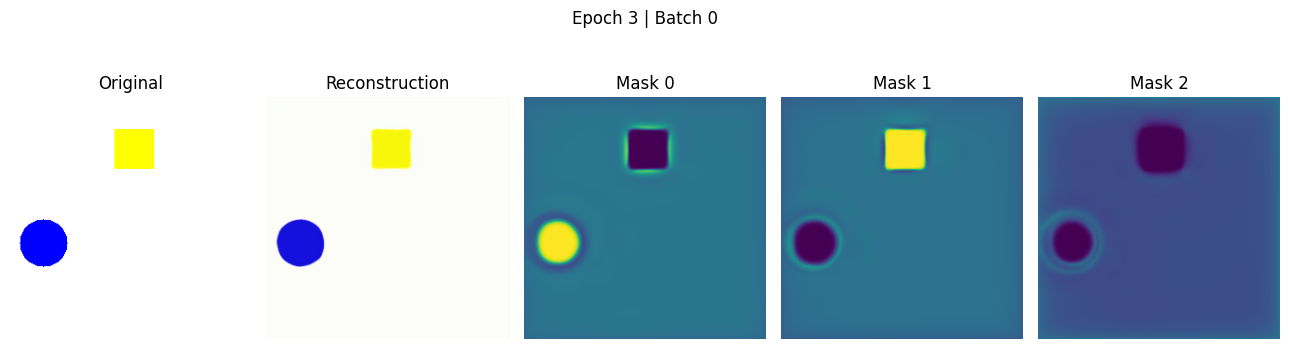

Epoch 3/10:  32%|███▏      | 20/63 [00:05<00:10,  4.11it/s, entropy_loss=0.0001, recon_loss=0.544, tv_loss=7.26e-6]  

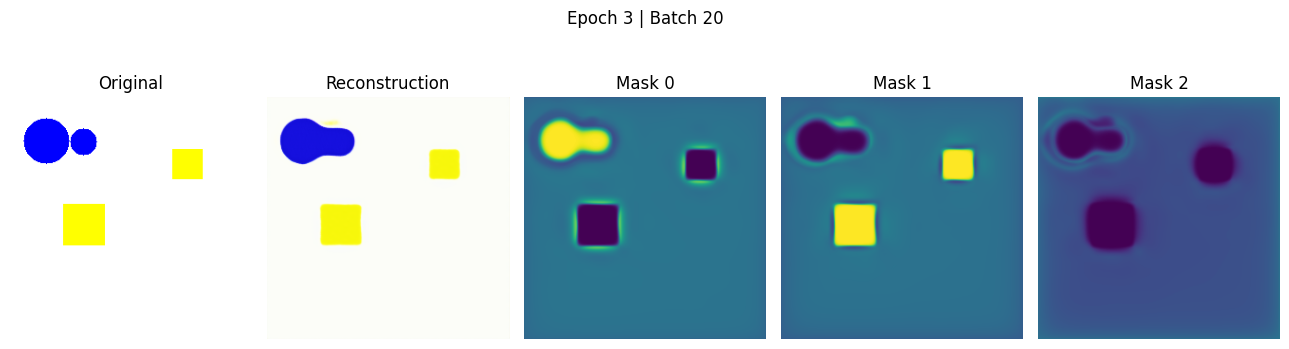

Epoch 3/10:  63%|██████▎   | 40/63 [00:10<00:05,  4.16it/s, entropy_loss=0.000101, recon_loss=0.535, tv_loss=6.8e-6] 

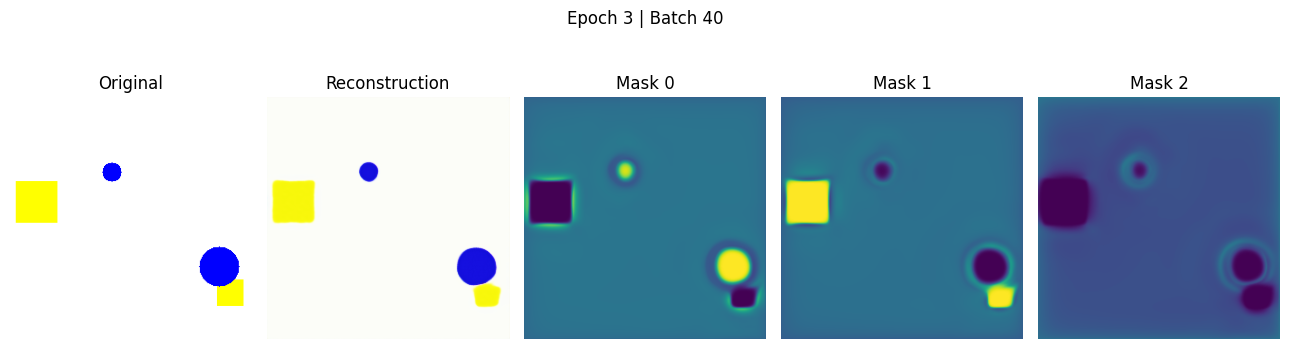

Epoch 3/10:  95%|█████████▌| 60/63 [00:15<00:00,  4.14it/s, entropy_loss=9.92e-5, recon_loss=0.56, tv_loss=7.43e-6]  

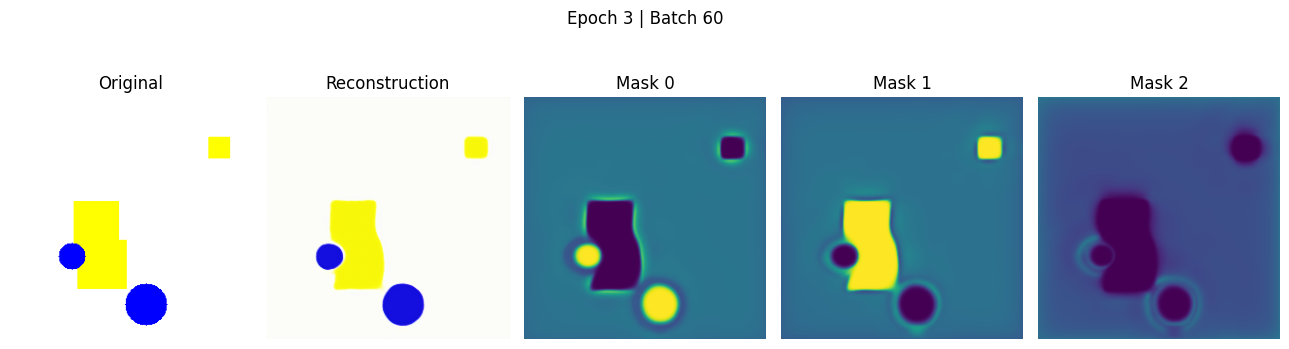

Epoch 3/10: 100%|██████████| 63/63 [00:16<00:00,  3.84it/s, entropy_loss=9.93e-5, recon_loss=0.527, tv_loss=7.81e-6]


Epoch 3 complete. Recon Loss: 0.5268


Epoch 4/10:   0%|          | 0/63 [00:00<?, ?it/s, entropy_loss=9.95e-5, recon_loss=0.558, tv_loss=7.78e-6]

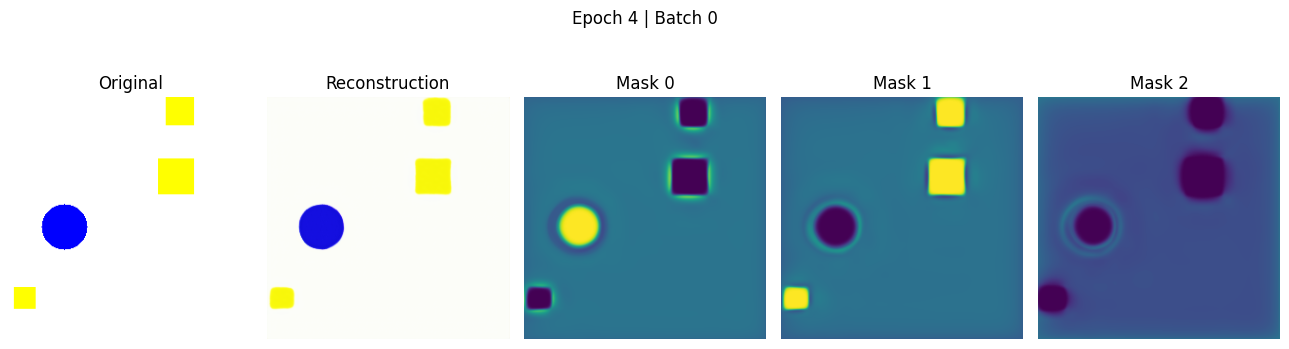

Epoch 4/10:  32%|███▏      | 20/63 [00:05<00:10,  4.04it/s, entropy_loss=9.86e-5, recon_loss=0.592, tv_loss=8.28e-6] 

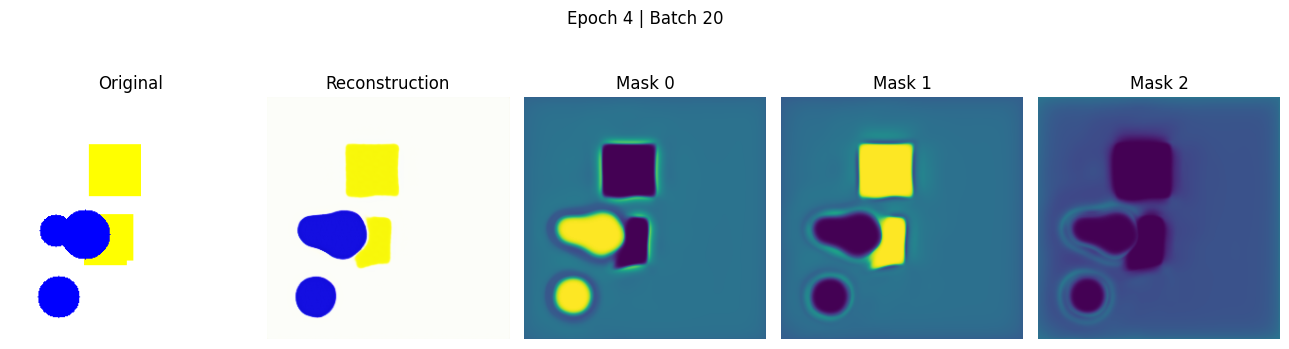

Epoch 4/10:  63%|██████▎   | 40/63 [00:10<00:05,  4.09it/s, entropy_loss=0.0001, recon_loss=0.531, tv_loss=7.33e-6]  

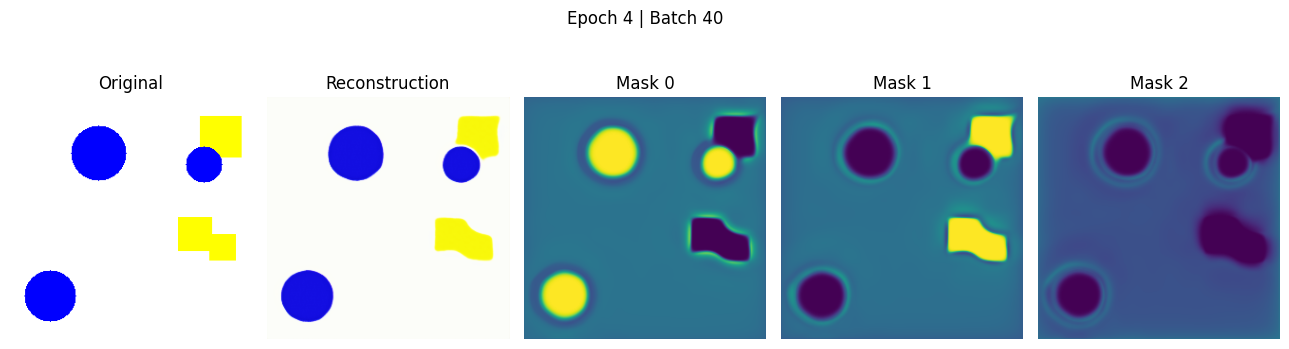

Epoch 4/10:  95%|█████████▌| 60/63 [00:15<00:00,  4.12it/s, entropy_loss=0.000102, recon_loss=0.457, tv_loss=6.52e-6]

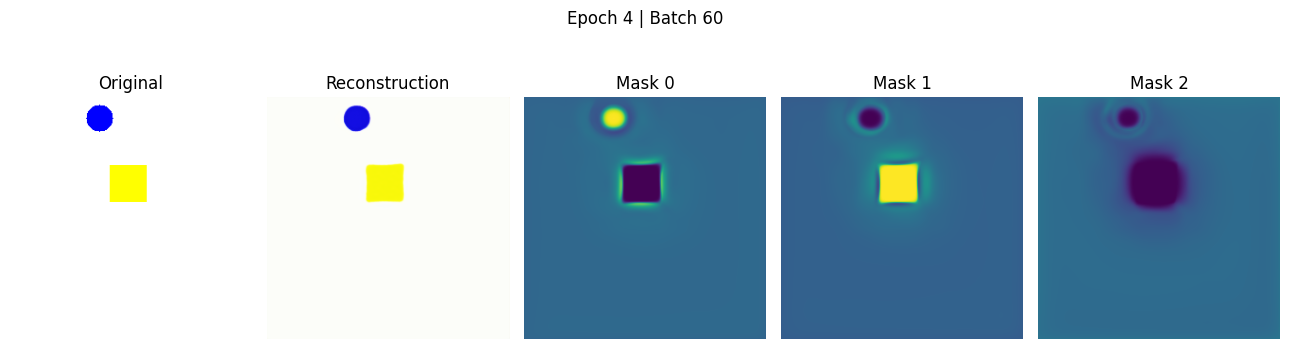

Epoch 4/10: 100%|██████████| 63/63 [00:16<00:00,  3.85it/s, entropy_loss=0.000102, recon_loss=0.447, tv_loss=6.74e-6]


Epoch 4 complete. Recon Loss: 0.4470


Epoch 5/10:   0%|          | 0/63 [00:00<?, ?it/s, entropy_loss=0.0001, recon_loss=0.514, tv_loss=7.01e-6]

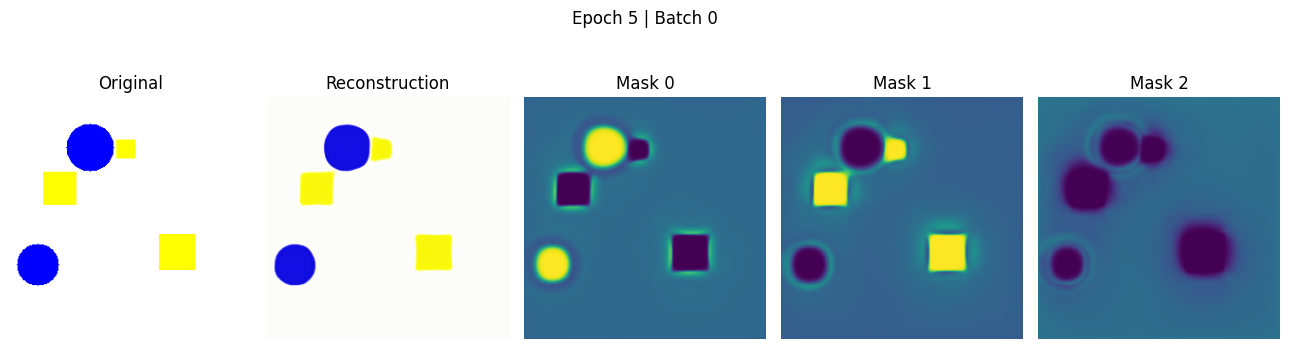

Epoch 5/10:  32%|███▏      | 20/63 [00:05<00:10,  4.11it/s, entropy_loss=0.000101, recon_loss=0.471, tv_loss=6.24e-6]

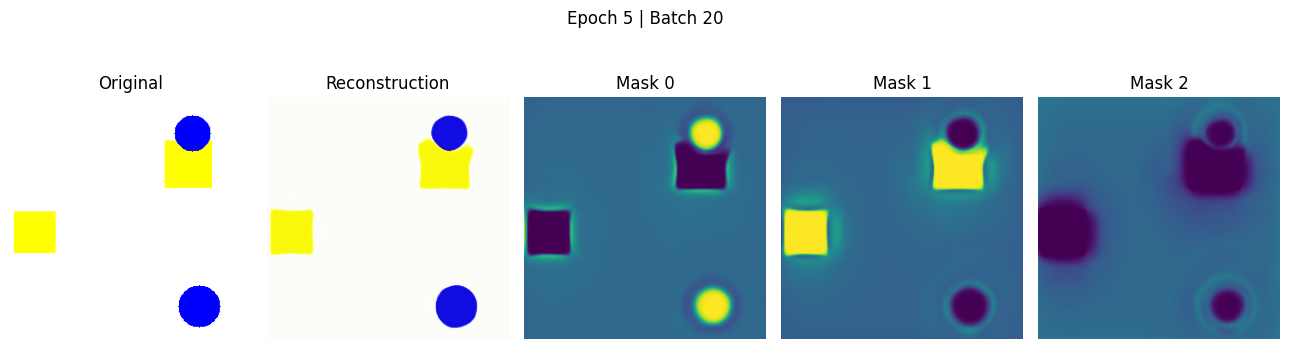

Epoch 5/10:  63%|██████▎   | 40/63 [00:10<00:05,  4.13it/s, entropy_loss=9.95e-5, recon_loss=0.508, tv_loss=7.26e-6] 

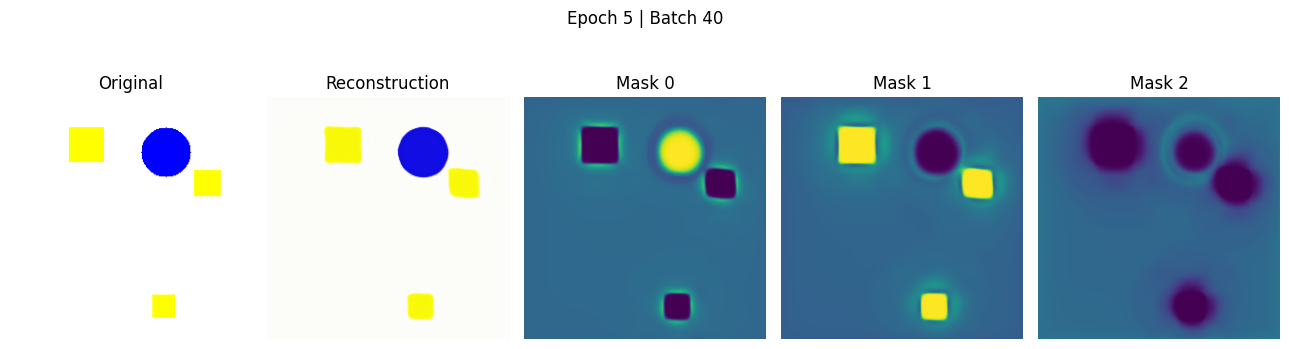

Epoch 5/10:  95%|█████████▌| 60/63 [00:15<00:00,  4.14it/s, entropy_loss=0.000101, recon_loss=0.535, tv_loss=6.7e-6] 

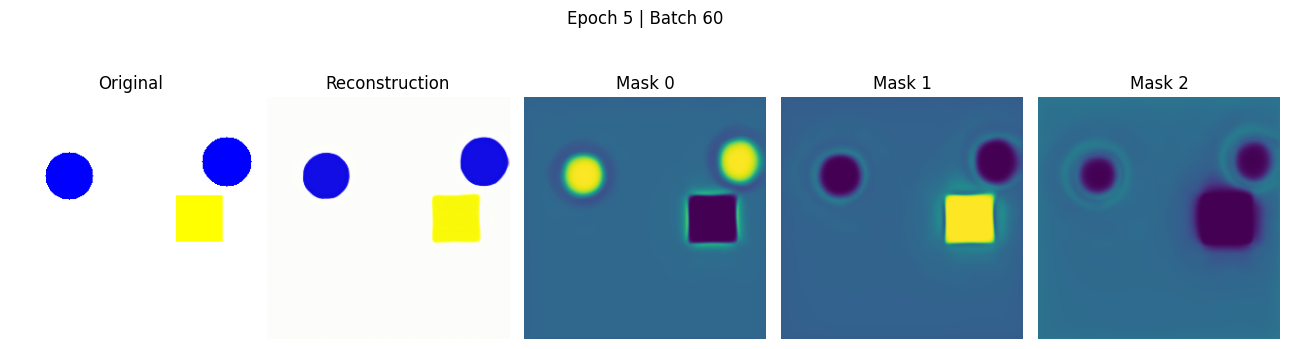

Epoch 5/10: 100%|██████████| 63/63 [00:16<00:00,  3.91it/s, entropy_loss=0.000101, recon_loss=0.492, tv_loss=6.69e-6]


Epoch 5 complete. Recon Loss: 0.4918


Epoch 6/10:   0%|          | 0/63 [00:00<?, ?it/s, entropy_loss=0.000101, recon_loss=0.51, tv_loss=6.99e-6]

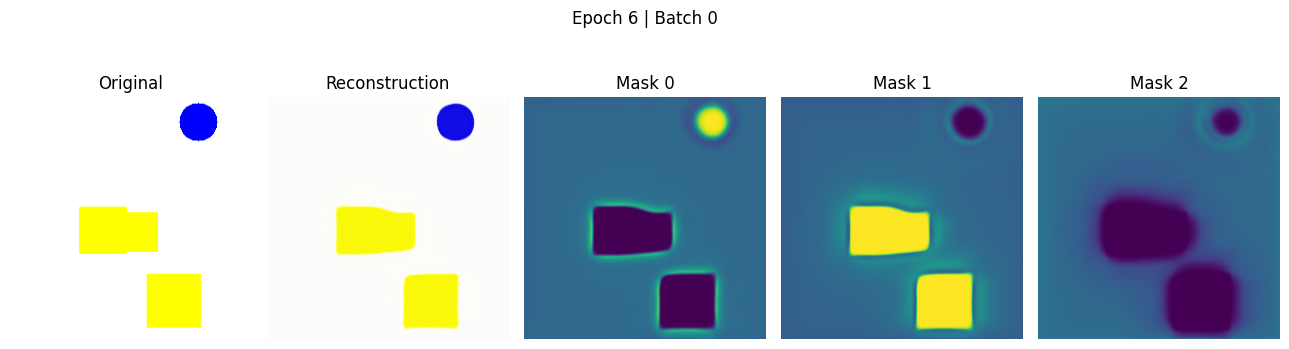

Epoch 6/10:  32%|███▏      | 20/63 [00:05<00:10,  4.16it/s, entropy_loss=9.98e-5, recon_loss=0.559, tv_loss=7.53e-6] 

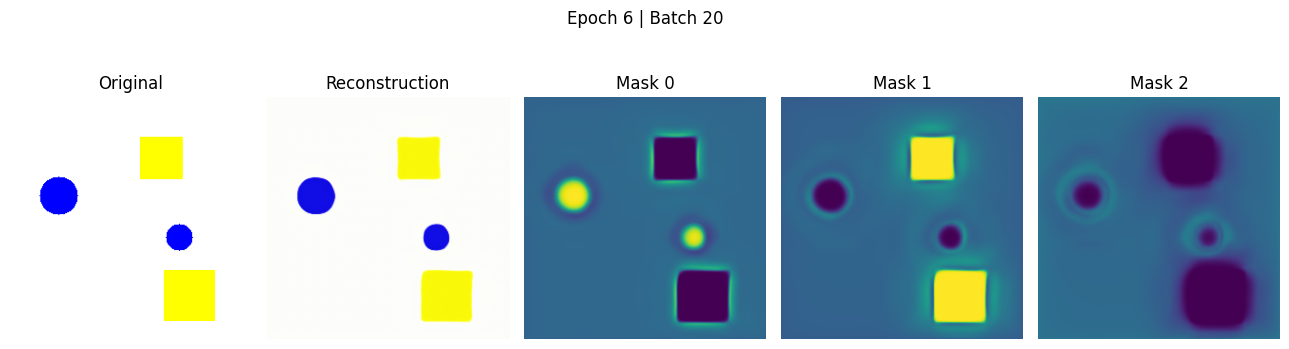

Epoch 6/10:  63%|██████▎   | 40/63 [00:10<00:05,  4.10it/s, entropy_loss=0.0001, recon_loss=0.536, tv_loss=7.24e-6]  

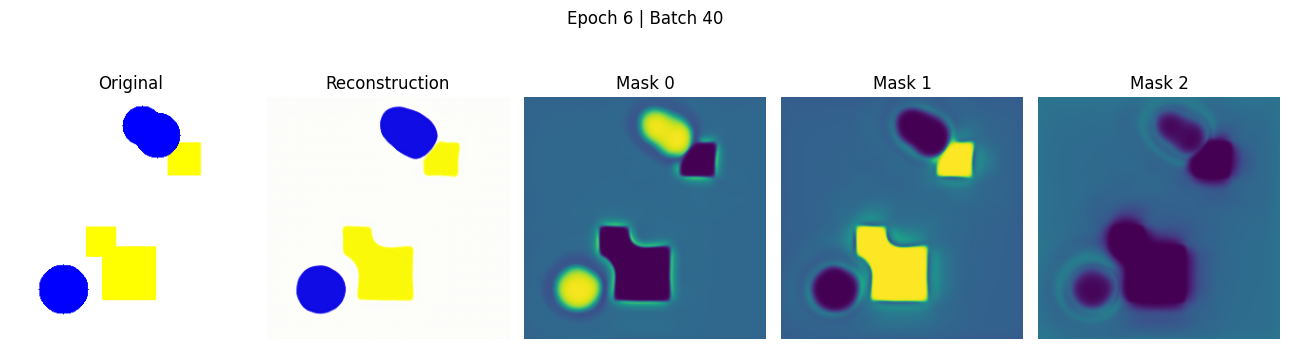

Epoch 6/10:  95%|█████████▌| 60/63 [00:15<00:00,  4.10it/s, entropy_loss=0.000101, recon_loss=0.499, tv_loss=6.88e-6]

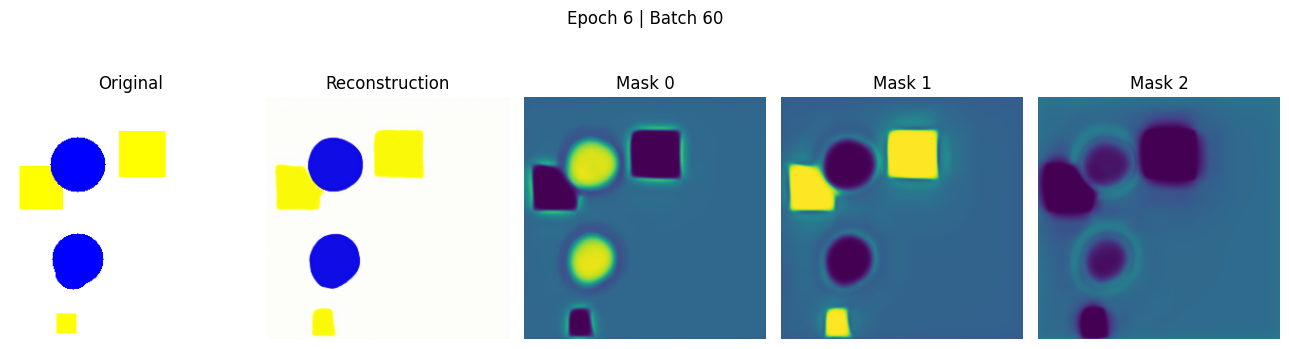

Epoch 6/10: 100%|██████████| 63/63 [00:16<00:00,  3.91it/s, entropy_loss=0.000102, recon_loss=0.552, tv_loss=7.05e-6]


Epoch 6 complete. Recon Loss: 0.5515


Epoch 7/10:   0%|          | 0/63 [00:00<?, ?it/s, entropy_loss=0.000102, recon_loss=0.457, tv_loss=6.32e-6]

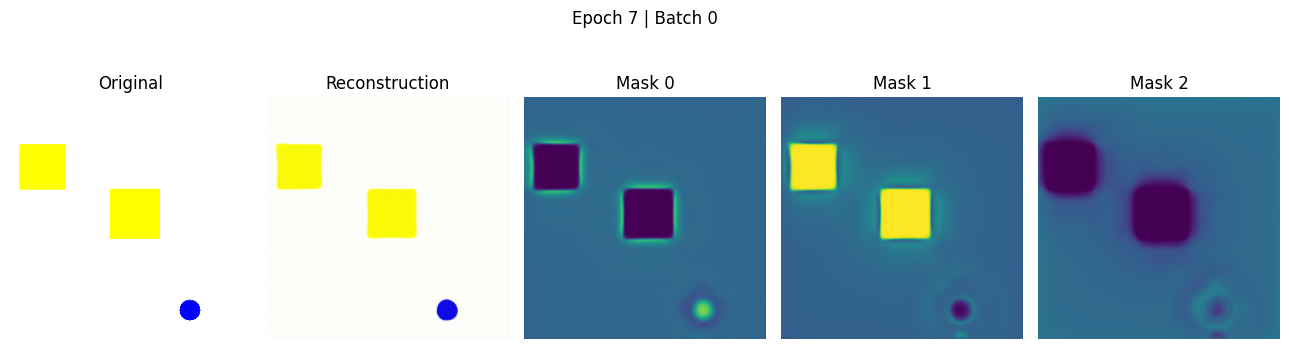

Epoch 7/10:  32%|███▏      | 20/63 [00:05<00:10,  4.07it/s, entropy_loss=0.000102, recon_loss=0.477, tv_loss=6.62e-6]

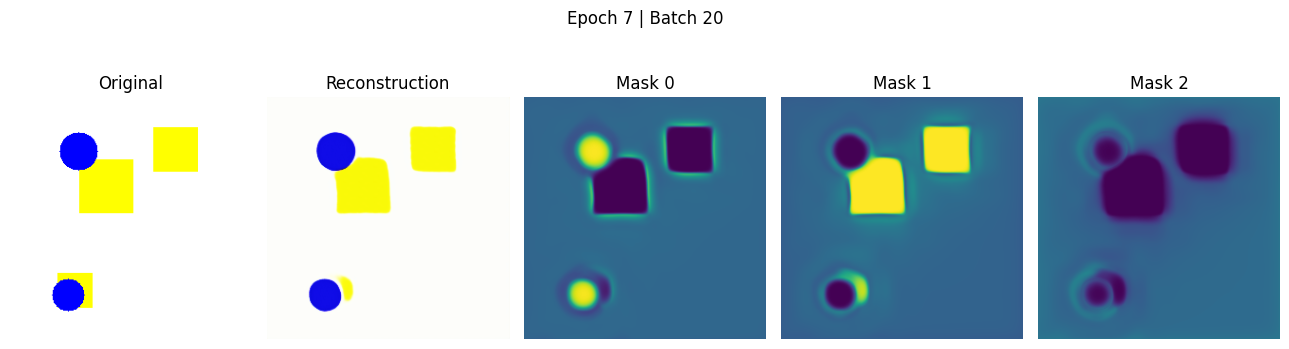

Epoch 7/10:  63%|██████▎   | 40/63 [00:10<00:05,  4.10it/s, entropy_loss=0.000101, recon_loss=0.522, tv_loss=7.21e-6]

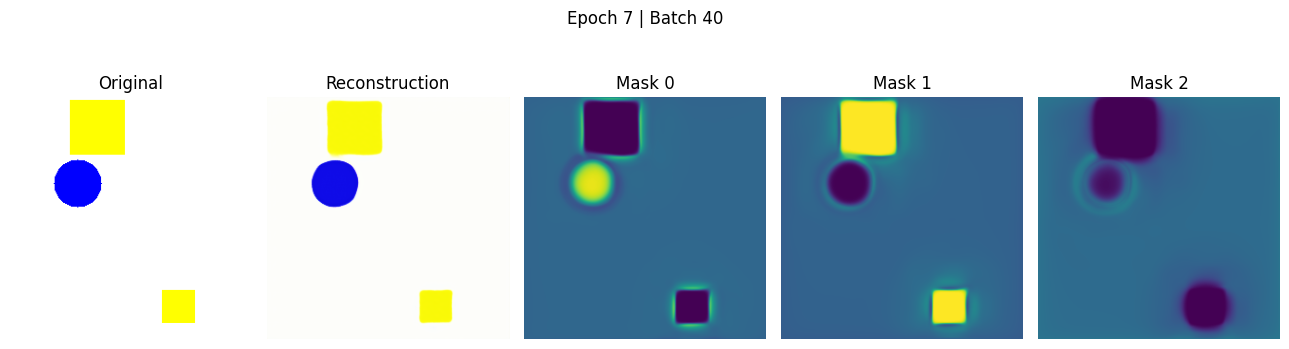

Epoch 7/10:  95%|█████████▌| 60/63 [00:15<00:00,  4.08it/s, entropy_loss=0.000102, recon_loss=0.448, tv_loss=6.66e-6]

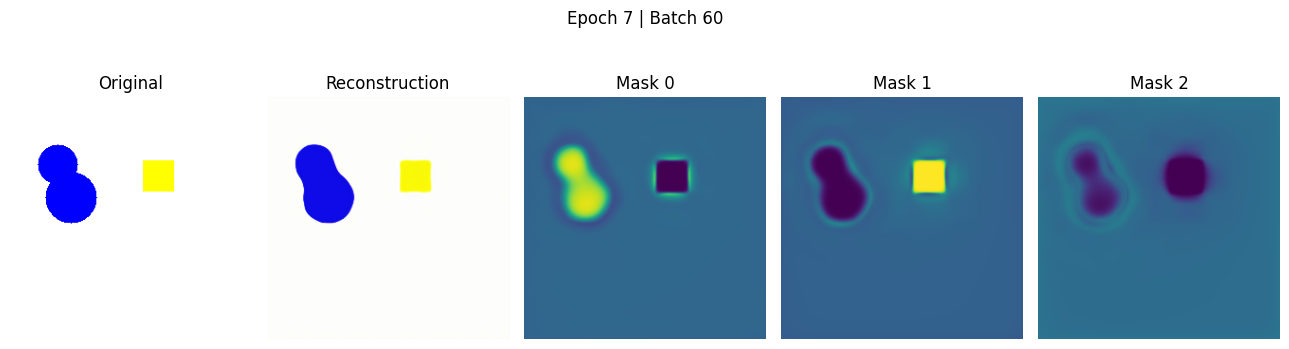

Epoch 7/10: 100%|██████████| 63/63 [00:16<00:00,  3.86it/s, entropy_loss=0.000101, recon_loss=0.466, tv_loss=6.7e-6] 


Epoch 7 complete. Recon Loss: 0.4663


Epoch 8/10:   0%|          | 0/63 [00:00<?, ?it/s, entropy_loss=0.000101, recon_loss=0.501, tv_loss=6.8e-6]

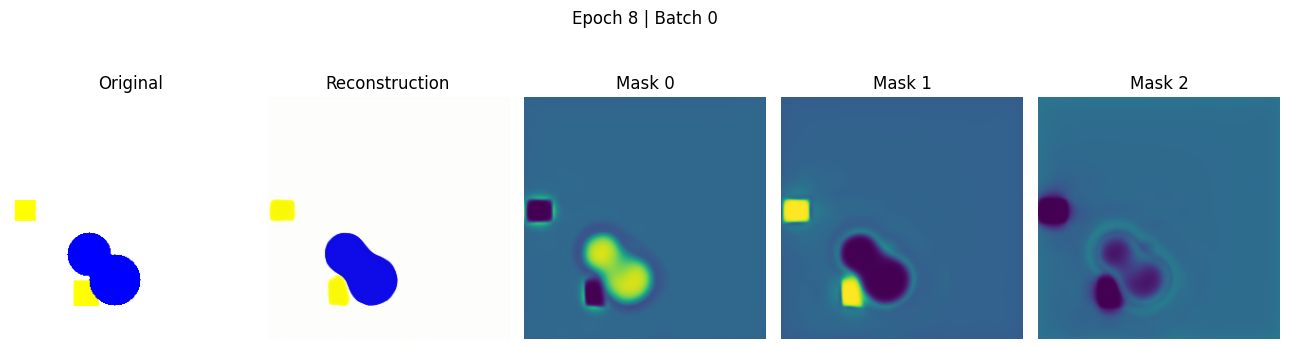

Epoch 8/10:  32%|███▏      | 20/63 [00:05<00:10,  4.09it/s, entropy_loss=0.000102, recon_loss=0.464, tv_loss=6.25e-6]

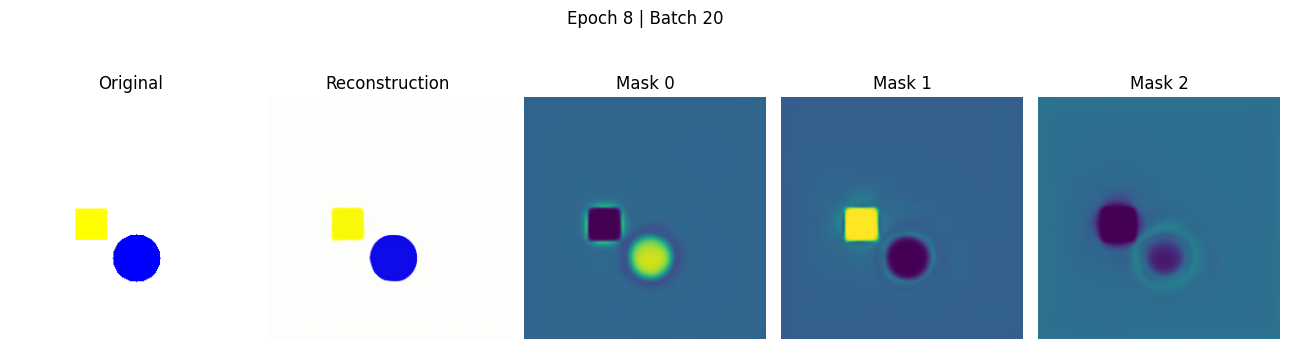

Epoch 8/10:  63%|██████▎   | 40/63 [00:10<00:05,  4.09it/s, entropy_loss=0.000103, recon_loss=0.476, tv_loss=6.37e-6]

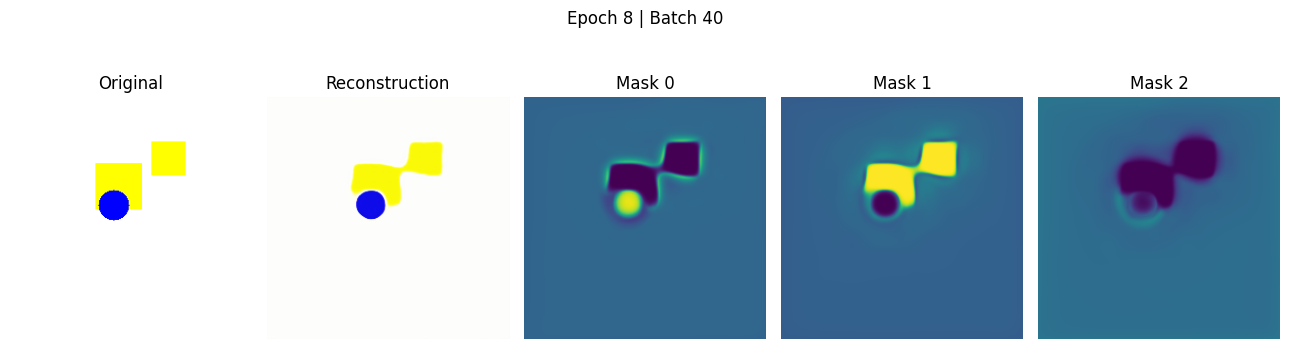

Epoch 8/10:  95%|█████████▌| 60/63 [00:15<00:00,  4.08it/s, entropy_loss=0.000103, recon_loss=0.406, tv_loss=6.07e-6]

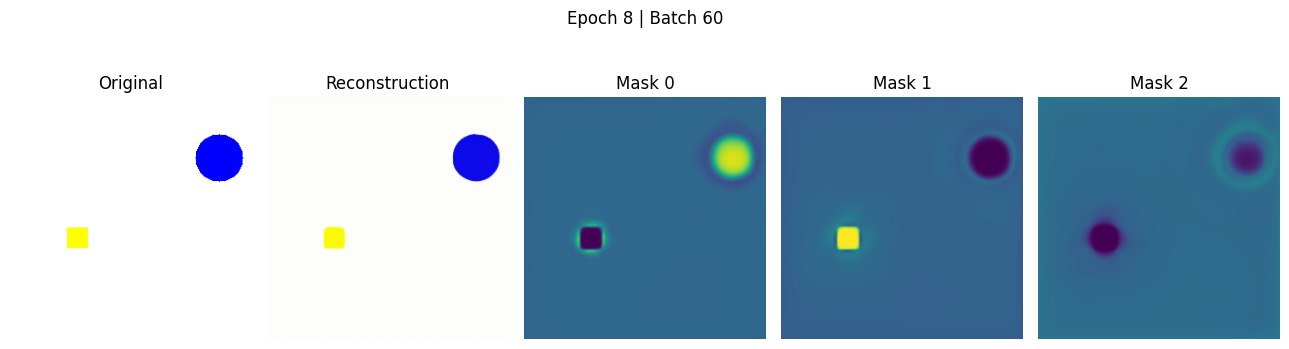

Epoch 8/10: 100%|██████████| 63/63 [00:16<00:00,  3.81it/s, entropy_loss=0.000102, recon_loss=0.468, tv_loss=6.69e-6]


Epoch 8 complete. Recon Loss: 0.4682


Epoch 9/10:   0%|          | 0/63 [00:00<?, ?it/s, entropy_loss=0.000101, recon_loss=0.456, tv_loss=6.52e-6]

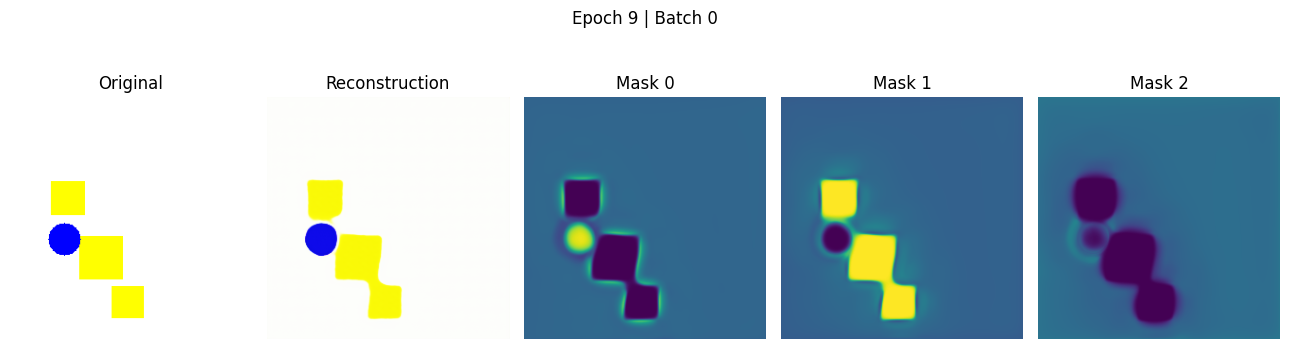

Epoch 9/10:  32%|███▏      | 20/63 [00:05<00:10,  4.07it/s, entropy_loss=0.000103, recon_loss=0.468, tv_loss=6.19e-6]

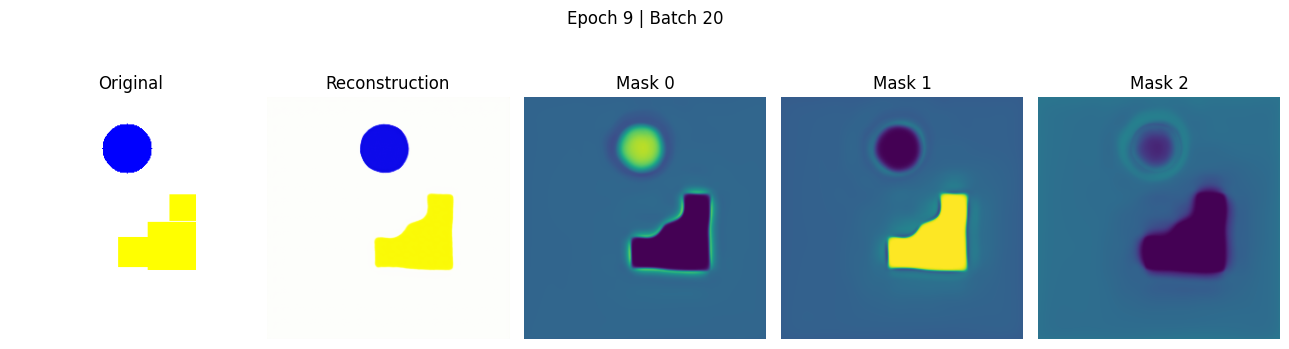

Epoch 9/10:  63%|██████▎   | 40/63 [00:10<00:05,  4.09it/s, entropy_loss=0.000102, recon_loss=0.464, tv_loss=6.54e-6]

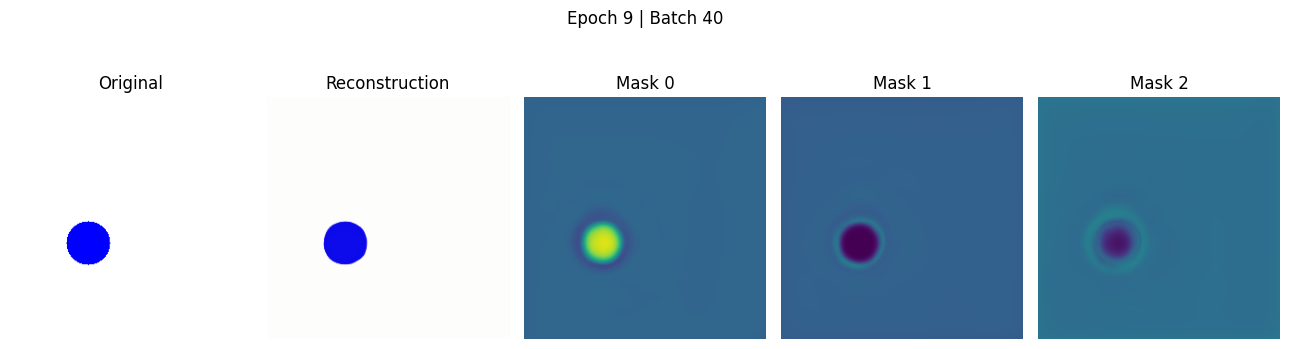

Epoch 9/10:  95%|█████████▌| 60/63 [00:15<00:00,  4.12it/s, entropy_loss=0.000102, recon_loss=0.447, tv_loss=6.48e-6]

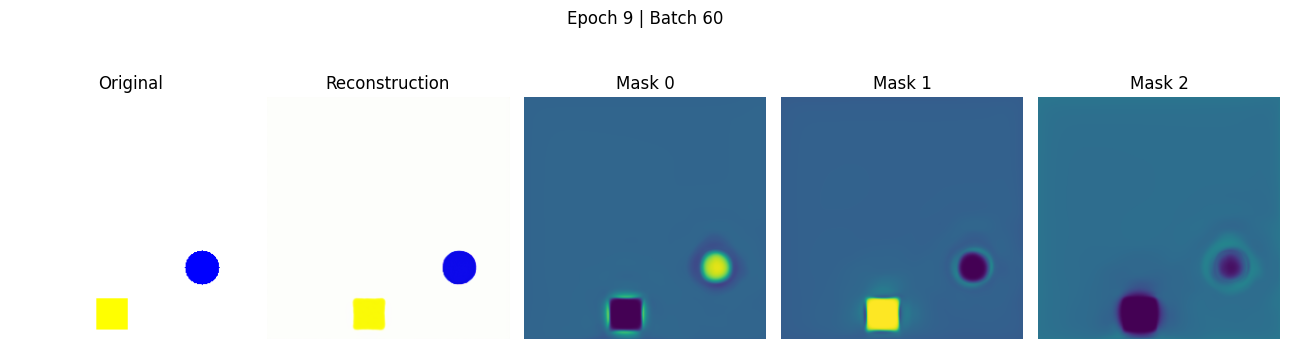

Epoch 9/10: 100%|██████████| 63/63 [00:16<00:00,  3.90it/s, entropy_loss=0.000103, recon_loss=0.455, tv_loss=6.22e-6]

Epoch 9 complete. Recon Loss: 0.4552


In [28]:
# Training Loop
for epoch in range(epochs):
    loop = tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}')
    for batch_idx, (data, _) in enumerate(loop):
        
        # Forward pass setup
        seg_optimizer.zero_grad()
        rec_optimizer.zero_grad()
        
        full_img = data[-1].to(device)
        
        seg_logits = seg_model(full_img)
        seg_probs = F.softmax(seg_logits, dim=1)
        reconstructions = rec_model(full_img, seg_probs)

        # Losses
        recon_loss = 0
        for target_img, pred_img in zip(data, reconstructions):
            target_img = target_img.to(device)
            recon_loss += recon_loss_fn(pred_img, target_img)
        
        tv_loss = tv_loss_fn(seg_probs)
        entropy_loss = entropy_loss_fn(seg_logits)
        
        # Total Loss & Backprop
        total_loss = recon_loss + entropy_loss + tv_loss
        total_loss.backward()
        
        seg_optimizer.step()
        rec_optimizer.step()
        
        loop.set_postfix(
            recon_loss=recon_loss.item(),
            entropy_loss=entropy_loss.item(),
            tv_loss=tv_loss.item(),
        )
        
        # Save visual progress every 20 batches
        if batch_idx % 20 == 0:
            # Pass seg_probs[0] to the visualization function
            visualize_results(full_img[0], reconstructions[-1][0], seg_probs[0], epoch, batch_idx)

    print(f"Epoch {epoch} complete. Recon Loss: {recon_loss.item():.4f}")